<a href="https://colab.research.google.com/github/NatanaelAnantaSatrio/SistemRekomendasi/blob/main/Praktikum3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# INSTALL VERSI YANG COMPATIBLE

!pip install numpy==1.26.4
!pip install scikit-surprise==1.1.4
!pip install scikit-learn==1.4.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 5.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp312-cp312-linux_x86_64.whl size=2554958 sha256=1c75f46df5f0c7b6b62c7cb7ecd44cb8ce2501b6ce42cda2c24d4bf3b9d733cf
  Stored in directory: /root/.cache/pip/wheels/75/fa/bc/739bc2cb1fbaab6061854e6cfbb81a0ae52c92a502a7fa454b
Successfully built scikit-surprise
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 38.7 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
umap-learn 0.5.12 requires sci

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# IMPORT LIBRARY

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from surprise import Dataset
from surprise import Reader
from surprise import SVD
from surprise.model_selection import train_test_split
from surprise.accuracy import rmse

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

from google.colab import drive

import warnings
warnings.filterwarnings('ignore')

In [ ]:
# LOAD DATASET

ratings = pd.read_csv(
    '/content/drive/MyDrive/Colab Notebooks/SistemRekomendasi/ratings.csv'
)

movies = pd.read_csv(
    '/content/drive/MyDrive/Colab Notebooks/SistemRekomendasi/movies.csv'
)

print(ratings.head())
print(movies.head())

   userId  movieId  rating   timestamp
0       1      296     5.0  1147880044
1       1      306     3.5  1147868817
2       1      307     5.0  1147868828
3       1      665     5.0  1147878820
4       1      899     3.5  1147868510
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  


In [ ]:
# CEK UKURAN DATASET

print("Ukuran Ratings :", ratings.shape)
print("Ukuran Movies  :", movies.shape)

Ukuran Ratings : (256880, 4)
Ukuran Movies  : (62423, 3)


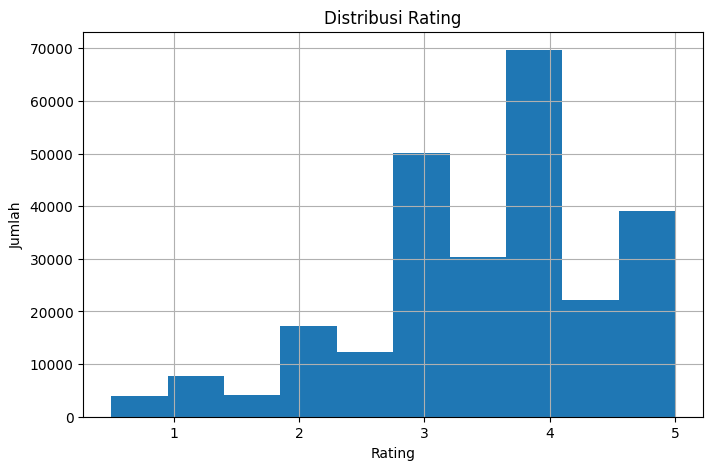

In [ ]:
# VISUALISASI DISTRIBUSI RATING

plt.figure(figsize=(8,5))

ratings['rating'].hist(bins=10)

plt.xlabel('Rating')
plt.ylabel('Jumlah')
plt.title('Distribusi Rating')

plt.show()

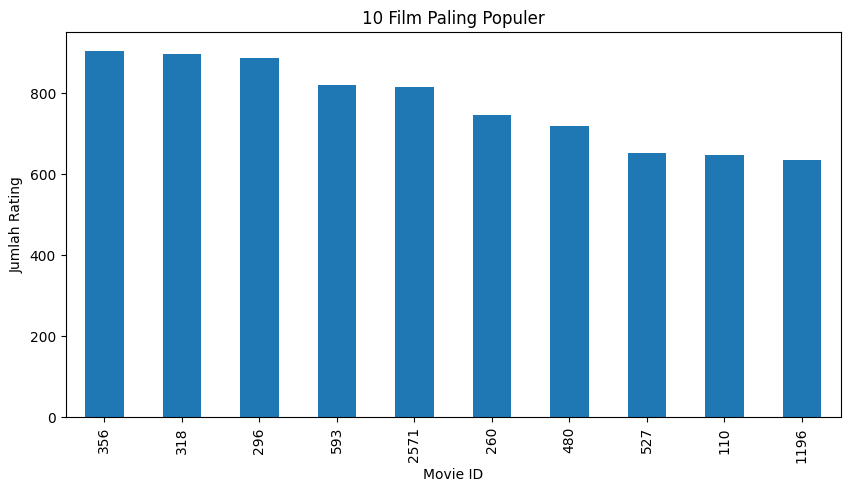

In [ ]:
# FILM PALING POPULER

popular_movies = ratings.groupby(
    'movieId'
).size().sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

popular_movies.plot(kind='bar')

plt.xlabel('Movie ID')
plt.ylabel('Jumlah Rating')
plt.title('10 Film Paling Populer')

plt.show()

In [ ]:
# MEMBUAT USER MOVIE MATRIX

user_movie_matrix = ratings.pivot_table(
    index='userId',
    columns='movieId',
    values='rating'
).fillna(0)

user_movie_matrix.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,205967,206272,206293,206499,206523,206805,206861,207309,208002,208793
userId,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# COSINE SIMILARITY

similarity = cosine_similarity(user_movie_matrix)

similarity_df = pd.DataFrame(similarity)

similarity_df.head()

,0,1,2,3,4,5,6,7,8,9,...,1809,1810,1811,1812,1813,1814,1815,1816,1817,1818
0,1.000000,0.040863,0.061306,0.040815,0.015609,0.000000,0.093852,0.021359,0.022860,0.026149,...,0.000000,0.032503,0.058512,0.045504,0.040398,0.034279,0.079646,0.039403,0.000000,0.000000
1,0.040863,1.000000,0.179009,0.197496,0.158202,0.129720,0.064954,0.176880,0.128820,0.156814,...,0.060128,0.134488,0.155751,0.090542,0.216915,0.247093,0.201028,0.088202,0.026935,0.000000
2,0.061306,0.179009,1.000000,0.357750,0.061448,0.115148,0.031427,0.081003,0.061602,0.132361,...,0.051567,0.137691,0.320807,0.131941,0.135547,0.147177,0.331350,0.062318,0.006683,0.083322
3,0.040815,0.197496,0.357750,1.000000,0.065825,0.072365,0.015566,0.088927,0.066428,0.083821,...,0.038230,0.082280,0.346221,0.148048,0.097028,0.212523,0.314150,0.080324,0.000000,0.071138
4,0.015609,0.158202,0.061448,0.065825,1.000000,0.114936,0.202348,0.307769,0.216435,0.269897,...,0.241303,0.168322,0.041310,0.000000,0.306304,0.144816,0.120777,0.099034,0.042441,0.000000


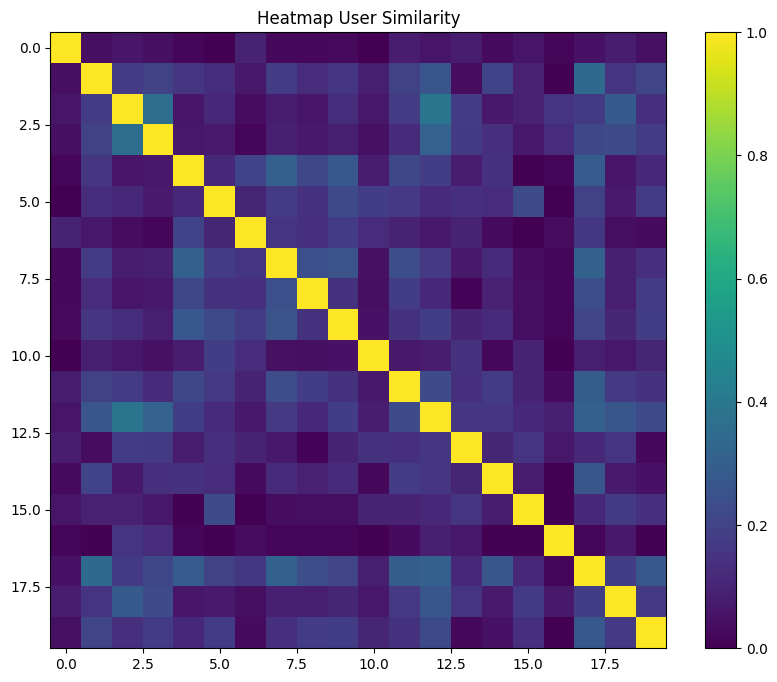

In [ ]:
# HEATMAP USER SIMILARITY

plt.figure(figsize=(10,8))

plt.imshow(similarity_df.iloc[:20, :20])

plt.colorbar()

plt.title('Heatmap User Similarity')

plt.show()

In [ ]:
# MATRIX FACTORIZATION DENGAN SVD

reader = Reader(rating_scale=(0.5, 5))

data = Dataset.load_from_df(
    ratings[['userId', 'movieId', 'rating']],
    reader
)

trainset, testset = train_test_split(
    data,
    test_size=0.2,
    random_state=42
)

model = SVD()

model.fit(trainset)

In [ ]:
predictions = model.test(testset)

rmse(predictions)

RMSE: 0.8687


0.868705085412303

In [ ]:
user_id = 1
movie_id = 50

pred = model.predict(user_id, movie_id)

print("Predicted Rating:", pred.est)

Predicted Rating: 4.723106001011093


In [ ]:
movie_ids = ratings['movieId'].unique()

predictions = []

for movie_id in movie_ids:
    pred = model.predict(1, movie_id)
    predictions.append((movie_id, pred.est))

predictions.sort(key=lambda x: x[1], reverse=True)

top_recommendations = predictions[:10]

movie_names = []
movie_scores = []

for movie_id, rating in top_recommendations:
    title = movies[movies['movieId'] == movie_id]['title'].values[0]

    movie_names.append(title)
    movie_scores.append(rating)

    print(title, ":", rating)

Pulp Fiction (1994) : 4.851411906861832
In the Mood For Love (Fa yeung nin wa) (2000) : 4.8467581689472725
Godfather, The (1972) : 4.768787037718459
Usual Suspects, The (1995) : 4.723106001011093
Godfather: Part II, The (1974) : 4.71446063977635
Good, the Bad and the Ugly, The (Buono, il brutto, il cattivo, Il) (1966) : 4.694491437529957
Shawshank Redemption, The (1994) : 4.624939839167178
Harold and Maude (1971) : 4.563586299250623
Seventh Seal, The (Sjunde inseglet, Det) (1957) : 4.551287397315676
Sling Blade (1996) : 4.544202522438881


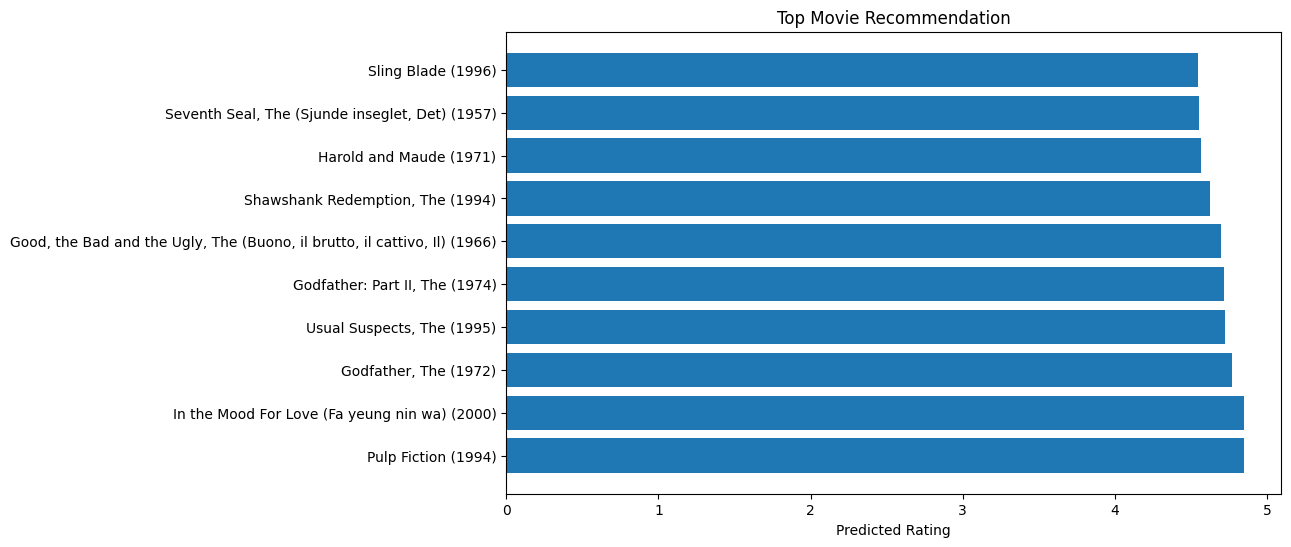

In [ ]:
plt.figure(figsize=(10,6))

plt.barh(movie_names, movie_scores)

plt.xlabel('Predicted Rating')
plt.title('Top Movie Recommendation')

plt.show()

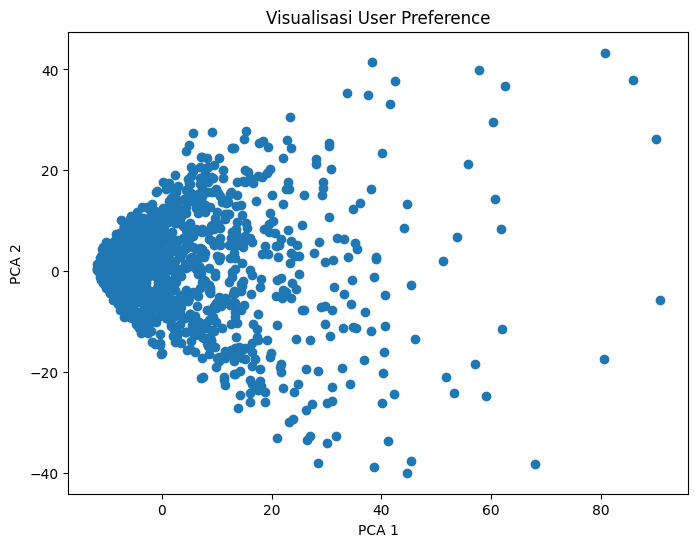

In [ ]:
pca = PCA(n_components=2)

reduced = pca.fit_transform(user_movie_matrix)

plt.figure(figsize=(8,6))

plt.scatter(reduced[:,0], reduced[:,1])

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Visualisasi User Preference')

plt.show()